In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio

from tqdm.auto import tqdm
from pathlib import Path

c:\Users\hermawan\AppData\Local\anaconda3\envs\egypt-gender\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
src_dir = (
    Path("~").expanduser()
    / "OneDrive - Stichting Deltares/PhD/Egypt/04_Data/2026_data/"
)
excel_path = (
    Path("~").expanduser()
    / "OneDrive - Stichting Deltares/PhD/Egypt/data_correlation.xlsx"
)


print (excel_path)


C:\Users\hermawan\OneDrive - Stichting Deltares\PhD\Egypt\data_correlation.xlsx


In [3]:
survey_df = pd.read_csv(src_dir.parent / "Result/ind_survey_data_gov_assigned.csv")
distribution_df = pd.read_csv(
    src_dir.parent / "Result/population_density_matrix.csv", index_col="NAME1_"
)
masking_df = pd.read_excel(
    src_dir.parent / "Result/correlation.xlsx", sheet_name="Sheet1"
)
excel_df = pd.read_excel(excel_path, sheet_name="command_unit")

In [4]:
print(f"Average survey weight: {survey_df['pweight'].mean()}")
print(f"Std of survey weight: {survey_df['pweight'].std()}")

Average survey weight: 341.13162810546737
Std of survey weight: 58.55064178032295


In [5]:
survey_df['sempinc'] = survey_df['sempinc'].fillna(0)
survey_df['irrgwag'] = survey_df['irrgwag'].fillna(0)
survey_df['totwag'] = survey_df['totwag'].fillna(0)

survey_df['totwag'] = survey_df['totwag'] + survey_df['sempinc'] + survey_df['irrgwag'] * 30

In [6]:
female_df = survey_df[survey_df['sex_label'] == 'Female']
male_df = survey_df[survey_df['sex_label'] == 'Male']

In [7]:
governorates = survey_df[survey_df["NAME1_"].notna()]["NAME1_"].unique()

rng = np.random.default_rng(seed=42)
sample_df = survey_df.copy(deep=True)
sample_df["command_unit"] = None
command_units = distribution_df.columns

gov_indices = {
    gov: idx.to_numpy() for gov, idx in survey_df.groupby("NAME1_").groups.items()
}
female_gov_indices = {
    gov: idx.to_numpy() for gov, idx in female_df.groupby("NAME1_").groups.items()
}
male_gov_indices = {
    gov: idx.to_numpy() for gov, idx in male_df.groupby("NAME1_").groups.items()
}

for gov, idx in gov_indices.items():
    probs = distribution_df.loc[gov].to_numpy()

    assignments = rng.choice(
        command_units,
        size=len(idx),
        p=probs,
    )

    sample_df.loc[idx, "command_unit"] = assignments

sample_df.loc[sample_df["command_unit"] == "other", "command_unit"] = None

sample_df = sample_df[sample_df["command_unit"].notna()]
final_sample = sample_df.merge(
    excel_df, left_on="command_unit", right_on="area", suffixes=("", "_spatial")
)

to_correlate = masking_df.loc[masking_df["correl"] == 1, "variable"]
cols = [c for c in to_correlate if c in final_sample.columns]

In [8]:
survey_df['numwrk'].unique()

array([ nan, 999., 130., 240., 400., 140.])

In [22]:
n_assignments = 1000
female_corrs = []
male_corrs = []
for i in tqdm(range(n_assignments)):
    assignment_df = female_df.copy(deep=True)
    assignment_df["command_unit"] = None

    for gov, idx in female_gov_indices.items():
        probs = distribution_df.loc[gov].to_numpy()

        assignments = rng.choice(
            command_units,
            size=len(idx),
            p=probs,
        )

        assignment_df.loc[idx, "command_unit"] = assignments

    assignment_df.loc[assignment_df["command_unit"] == "other", "command_unit"] = None

    assignment_df = assignment_df[assignment_df["command_unit"].notna()]
    assignment_df = assignment_df.merge(
        excel_df, left_on="command_unit", right_on="area", suffixes=("", "_spatial")
    )

    cor_df = assignment_df[cols]
    cor_df["command_unit"] = cor_df["command_unit"].apply(
        lambda x: int(x.split("_")[-1])
    )

    corr_matrix = cor_df.corr(method="pearson")
    female_corrs.append(corr_matrix)

for i in tqdm(range(n_assignments)):
    assignment_df = male_df.copy(deep=True)
    assignment_df["command_unit"] = None

    for gov, idx in male_gov_indices.items():
        probs = distribution_df.loc[gov].to_numpy()

        assignments = rng.choice(
            command_units,
            size=len(idx),
            p=probs,
        )

        assignment_df.loc[idx, "command_unit"] = assignments

    assignment_df.loc[assignment_df["command_unit"] == "other", "command_unit"] = None

    assignment_df = assignment_df[assignment_df["command_unit"].notna()]
    assignment_df = assignment_df.merge(
        excel_df, left_on="command_unit", right_on="area", suffixes=("", "_spatial")
    )

    cor_df = assignment_df[cols]
    cor_df["command_unit"] = cor_df["command_unit"].apply(
        lambda x: int(x.split("_")[-1])
    )

    corr_matrix = cor_df.corr(method="pearson")
    male_corrs.append(corr_matrix)

100%|██████████| 1000/1000 [01:34<00:00, 10.54it/s]


In [23]:
for col in cols:
    corr = np.corrcoef(
        assignment_df["pweight"],
        cor_df[col]
    )[0, 1]
    print(col, corr)

age -0.13306607103886545
sex nan
mart_d nan
immigr nan
disabl nan
lit 0.03832638730273659
yeduc nan
emps 0.029831077618581673
tenure -0.14648280174406494
empstab -0.07386204333908285
hlthins 0.01666598121513498
socsec -0.030050802378905787
numwrk nan
hrswk 0.13860829188506
secjob 0.007884510425805536
hrswksc nan
totwag 0.05637743814179836
unempdur nan
household_size 0.012338120093230482
n_other_employed -0.0630768708085496
command_unit -0.06385499194841425
water_productivity -0.224103698445005
surface_water_mean -0.1331655977572816
ground_water_mean 0.05867993596980993
supply_demand_ratio 0.061844707194618535
water_supply -0.07626533829658269
water_demand -0.07040229848269088
gdp_pc -0.11267151420586902
rwi_median -0.08294472493754623
precipitation 0.27599689451530823
potentialevapotransporation -0.31079148382040467
drain_length 0.044642389909736145
canal_length -0.0378407221490107
cattle -0.007652268821807742
chicken 0.08185678370177127
goats -0.09840226796084937
sheeps -0.12769183829

c:\Users\hermawan\AppData\Local\anaconda3\envs\egypt-gender\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\hermawan\AppData\Local\anaconda3\envs\egypt-gender\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [24]:
female_corr_array = np.stack([c.to_numpy() for c in female_corrs])
male_corr_array = np.stack([c.to_numpy() for c in male_corrs])

cols_corr = female_corrs[0].columns

In [25]:
for col in cols:
    print(
        col,
        assignment_df[col].nunique(dropna=True),
        assignment_df[col].isna().mean()
    )

age 72 0.0
sex 1 0.0
mart_d 7 0.024652709841518294
immigr 3 0.7526902758755625
disabl 2 0.7526902758755625
lit 2 0.0
yeduc 15 9.782821365681862e-05
emps 4 0.0
tenure 65 0.0
empstab 3 0.0
hlthins 2 0.0
socsec 2 0.0
numwrk 5 0.9962825278810409
hrswk 76 0.0
secjob 2 0.0
hrswksc 29 0.9842496576012522
totwag 163 0.0
unempdur 0 1.0
household_size 14 0.0
n_other_employed 7 0.0
command_unit 59 0.0
water_productivity 57 0.0
surface_water_mean 59 0.0
ground_water_mean 58 0.0
supply_demand_ratio 59 0.0
water_supply 57 0.0
water_demand 57 0.0
gdp_pc 59 0.0
rwi_median 58 0.0
precipitation 59 0.0
potentialevapotransporation 59 0.0
drain_length 59 0.0
canal_length 59 0.0
cattle 59 0.0
chicken 59 0.0
goats 59 0.0
sheeps 59 0.0
salinity_production_Maize (incl. 0067 and 0068) 1 0.0
salinity_cultivation_area_Maize (incl. 0067 and 0068) 56 0.0
salinity_production_Wheat 57 0.0
salinity_cultivation_area_Wheat 57 0.0
salinity_production_Rice, paddy 1 0.0
salinity_cultivation_area_Rice, paddy 45 0.0
salinity_

In [26]:
# avoid infinities for correlations exactly -1 or 1
female_corr_clipped = np.clip(female_corr_array, -0.999999, 0.999999)
male_corr_clipped = np.clip(male_corr_array, -0.999999, 0.999999)

female_z_array = np.arctanh(female_corr_clipped)
male_z_array = np.arctanh(male_corr_clipped)

female_mean_z = np.nanmean(female_z_array, axis=0)
male_mean_z = np.nanmean(male_z_array, axis=0)

female_mean_corr = np.tanh(female_mean_z)
male_mean_corr = np.tanh(male_mean_z)

female_mean_corr_df = pd.DataFrame(
    female_mean_corr,
    index=cols_corr,
    columns=cols_corr,
)

male_mean_corr_df = pd.DataFrame(
    male_mean_corr,
    index=cols_corr,
    columns=cols_corr,
)

C:\Users\hermawan\AppData\Local\Temp\ipykernel_22656\633574474.py:8: RuntimeWarning: Mean of empty slice
  female_mean_z = np.nanmean(female_z_array, axis=0)
C:\Users\hermawan\AppData\Local\Temp\ipykernel_22656\633574474.py:9: RuntimeWarning: Mean of empty slice
  male_mean_z = np.nanmean(male_z_array, axis=0)


In [27]:
female_std_corr = np.nanstd(female_corr_array, axis=0)

female_std_corr_df = pd.DataFrame(
    female_std_corr,
    index=cols_corr,
    columns=cols_corr,
)

male_std_corr = np.nanstd(male_corr_array, axis=0)

male_std_corr_df = pd.DataFrame(
    male_std_corr,
    index=cols_corr,
    columns=cols_corr,
)

c:\Users\hermawan\AppData\Local\anaconda3\envs\egypt-gender\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [28]:
female_p05_corr = np.nanpercentile(female_corr_array, 5, axis=0)
female_p50_corr = np.nanpercentile(female_corr_array, 50, axis=0)
female_p95_corr = np.nanpercentile(female_corr_array, 95, axis=0)

female_p05_corr_df = pd.DataFrame(female_p05_corr, index=cols_corr, columns=cols_corr)
female_p50_corr_df = pd.DataFrame(female_p50_corr, index=cols_corr, columns=cols_corr)
female_p95_corr_df = pd.DataFrame(female_p95_corr, index=cols_corr, columns=cols_corr)

male_p05_corr = np.nanpercentile(male_corr_array, 5, axis=0)
male_p50_corr = np.nanpercentile(male_corr_array, 50, axis=0)
male_p95_corr = np.nanpercentile(male_corr_array, 95, axis=0)

male_p05_corr_df = pd.DataFrame(male_p05_corr, index=cols_corr, columns=cols_corr)
male_p50_corr_df = pd.DataFrame(male_p50_corr, index=cols_corr, columns=cols_corr)
male_p95_corr_df = pd.DataFrame(male_p95_corr, index=cols_corr, columns=cols_corr)

c:\Users\hermawan\AppData\Local\anaconda3\envs\egypt-gender\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [29]:
female_positive_fraction = np.nanmean(female_corr_array > 0, axis=0)
female_negative_fraction = np.nanmean(female_corr_array < 0, axis=0)

female_positive_fraction_df = pd.DataFrame(
    female_positive_fraction,
    index=cols_corr,
    columns=cols_corr,
)

female_negative_fraction_df = pd.DataFrame(
    female_negative_fraction,
    index=cols_corr,
    columns=cols_corr,
)

male_positive_fraction = np.nanmean(male_corr_array > 0, axis=0)
male_negative_fraction = np.nanmean(male_corr_array < 0, axis=0)

male_positive_fraction_df = pd.DataFrame(
    male_positive_fraction,
    index=cols_corr,
    columns=cols_corr,
)

male_negative_fraction_df = pd.DataFrame(
    male_negative_fraction,
    index=cols_corr,
    columns=cols_corr,
)

In [30]:
female_summary_records = []

for row_var in cols_corr:
    for col_var in cols_corr:
        if row_var == col_var:
            continue

        i = cols_corr.get_loc(row_var)
        j = cols_corr.get_loc(col_var)

        female_summary_records.append(
            {
                "var_1": row_var,
                "var_2": col_var,
                "mean_r": female_mean_corr[i, j],
                "std_r": female_std_corr[i, j],
                "p05_r": female_p05_corr[i, j],
                "p50_r": female_p50_corr[i, j],
                "p95_r": female_p95_corr[i, j],
                "positive_fraction": female_positive_fraction[i, j],
                "negative_fraction": female_negative_fraction[i, j],
            }
        )

female_corr_summary_df = pd.DataFrame(female_summary_records)

male_summary_records = []

for row_var in cols_corr:
    for col_var in cols_corr:
        if row_var == col_var:
            continue

        i = cols_corr.get_loc(row_var)
        j = cols_corr.get_loc(col_var)

        male_summary_records.append(
            {
                "var_1": row_var,
                "var_2": col_var,
                "mean_r": male_mean_corr[i, j],
                "std_r": male_std_corr[i, j],
                "p05_r": male_p05_corr[i, j],
                "p50_r": male_p50_corr[i, j],
                "p95_r": male_p95_corr[i, j],
                "positive_fraction": male_positive_fraction[i, j],
                "negative_fraction": male_negative_fraction[i, j],
            }
        )

male_corr_summary_df = pd.DataFrame(male_summary_records)

In [34]:
female_corr_summary_df.sort_values(by="std_r", ascending=False)

female_corr_summary_df.to_csv("female_corr_summary_sorted.csv", index=False)
male_corr_summary_df.to_csv("male_corr_summary_sorted.csv", index=False)

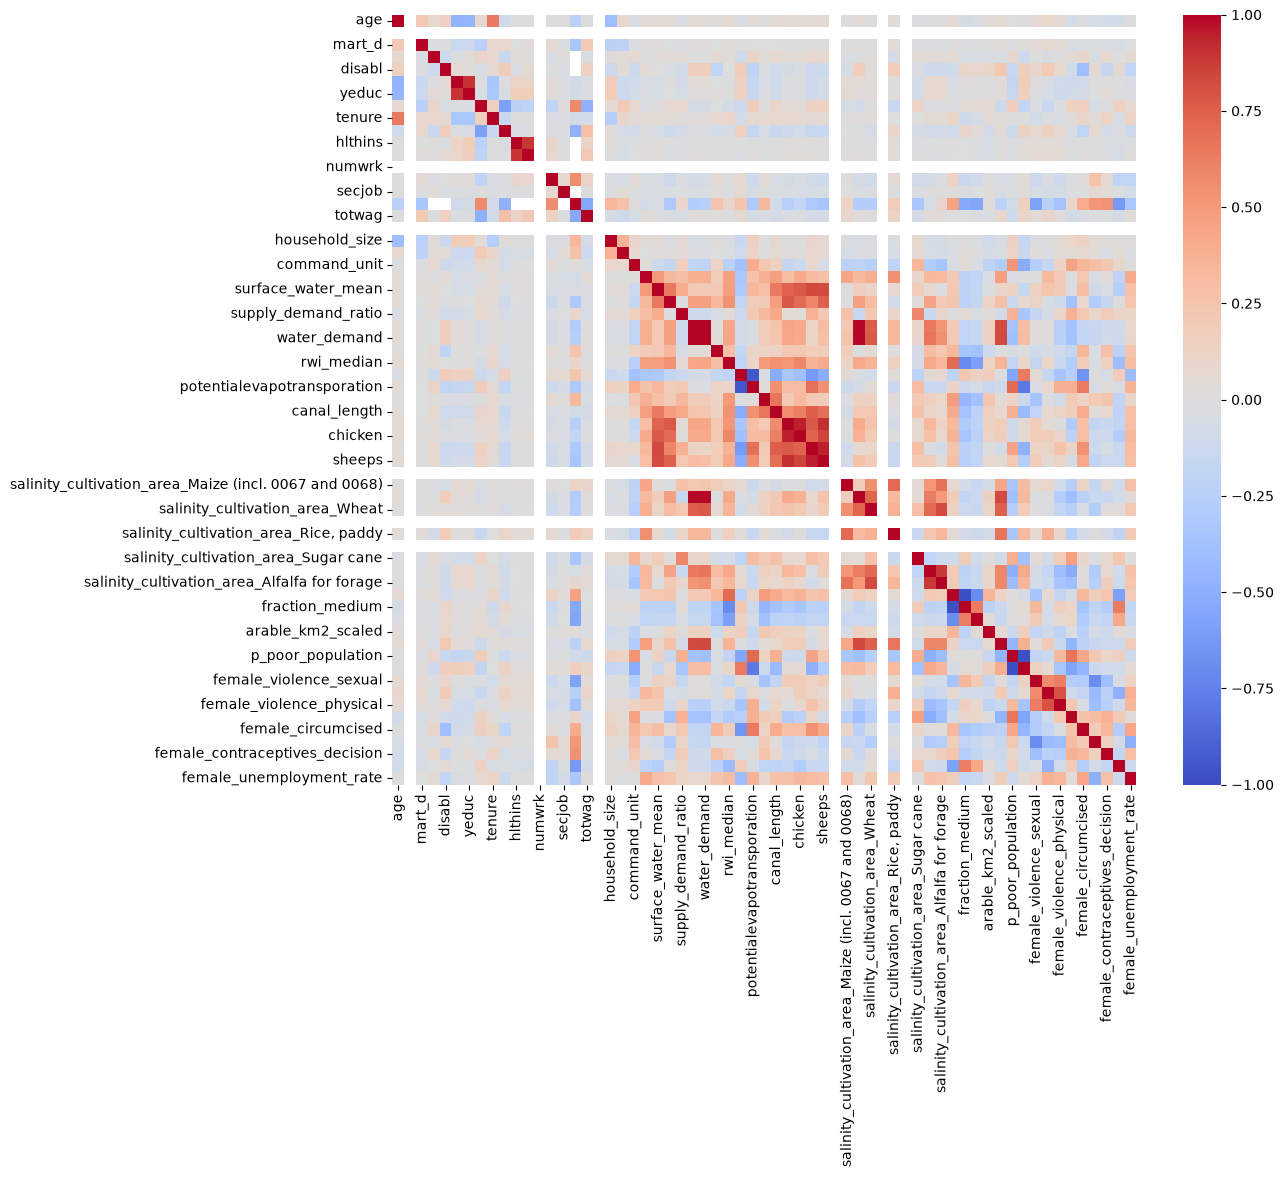

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(
    female_mean_corr_df,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
)
plt.show()

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    male_mean_corr_df,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
)
plt.show()

In [ ]:
female_corr_long = female_mean_corr_df.abs().stack().reset_index()

female_corr_long.columns = ["var1", "var2", "corr"]

female_corr_long = female_corr_long[female_corr_long["var1"] < female_corr_long["var2"]]

female_corr_long.sort_values("corr", ascending=False).head(40)

In [ ]:
male_corr_long = male_mean_corr_df.abs().stack().reset_index()

male_corr_long.columns = ["var1", "var2", "corr"]

male_corr_long = male_corr_long[male_corr_long["var1"] < male_corr_long["var2"]]

male_corr_long.sort_values("corr", ascending=False).head(40)